In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
df = pd.read_csv("winequality-red.csv", sep=";")
print(df.columns.tolist())
print("Shape:", df.shape)
df.head()

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [27]:
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicate rows: 240


quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


/tmp/ipykernel_2947/2288361975.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


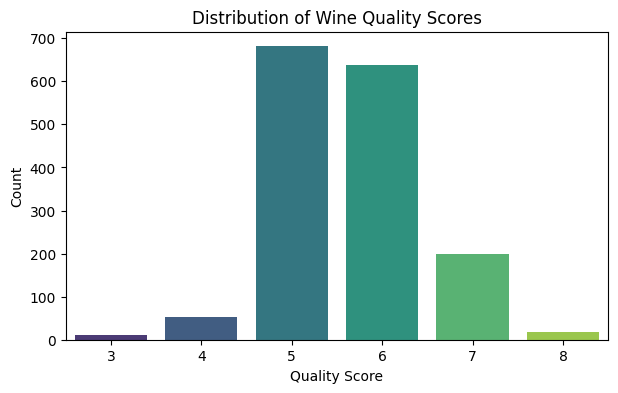

In [28]:
print(df['quality'].value_counts().sort_index())

plt.figure(figsize=(7,4))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()

"Quality scores are heavily skewed towards 5 and 6, with very few samples at extremes (3, 4, 8). This means a model could achieve high accuracy just by always predicting the majority class, so accuracy alone is misleading — we'll rely on precision/recall/F1 per class too."

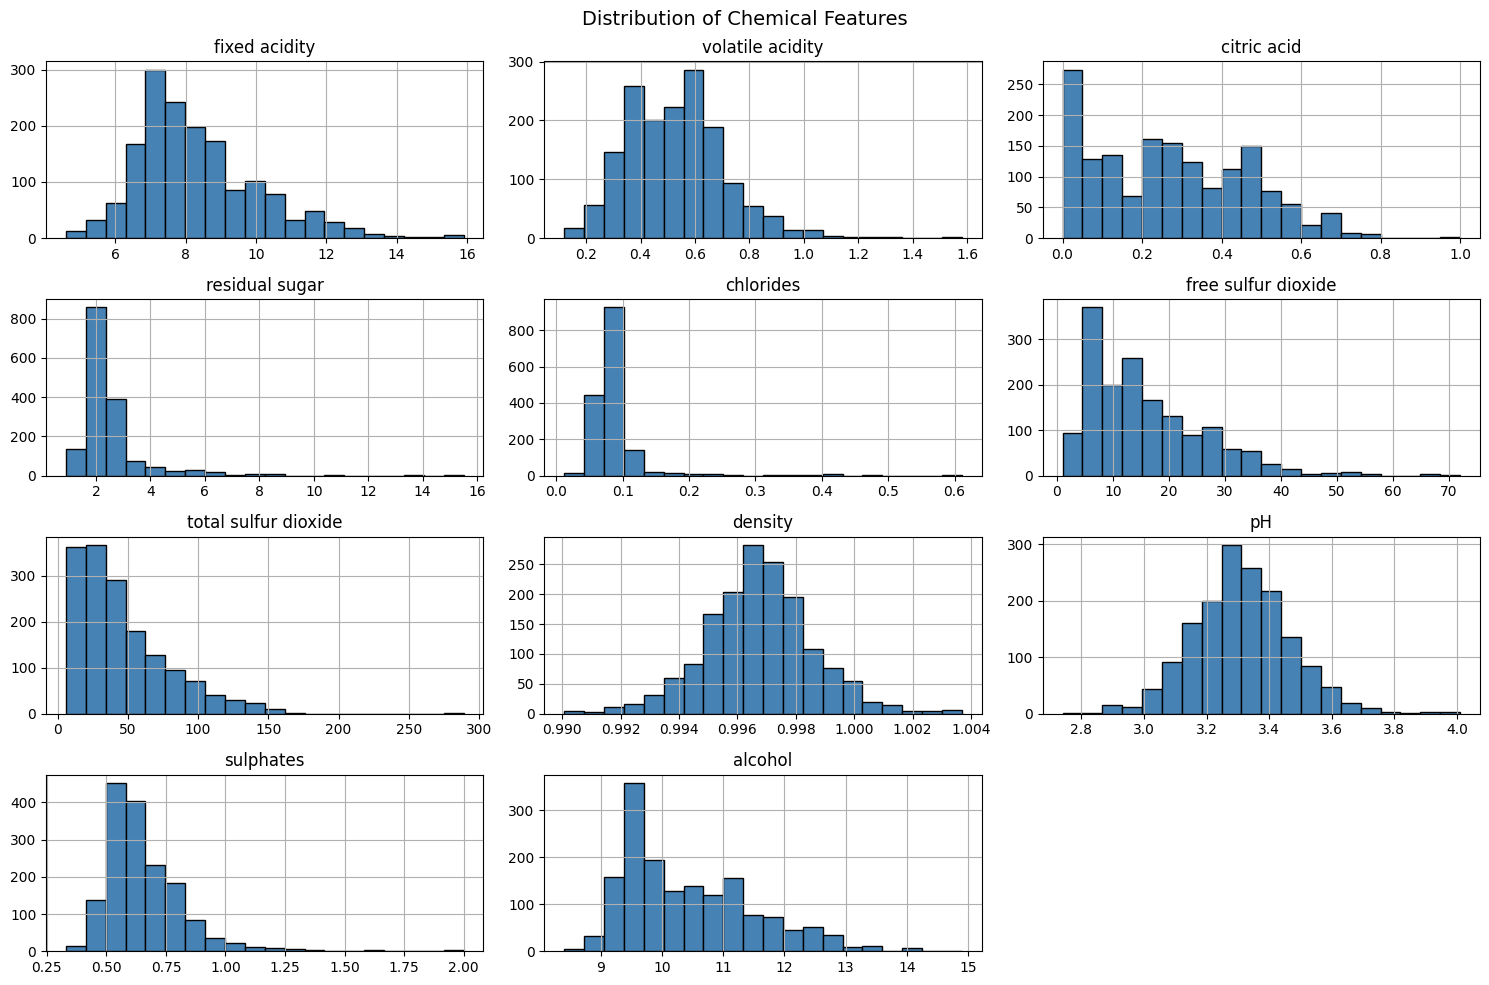

In [29]:
features = df.columns.drop('quality')
df[features].hist(bins=20, figsize=(15,10), color='steelblue', edgecolor='black')
plt.suptitle("Distribution of Chemical Features", fontsize=14)
plt.tight_layout()
plt.show()

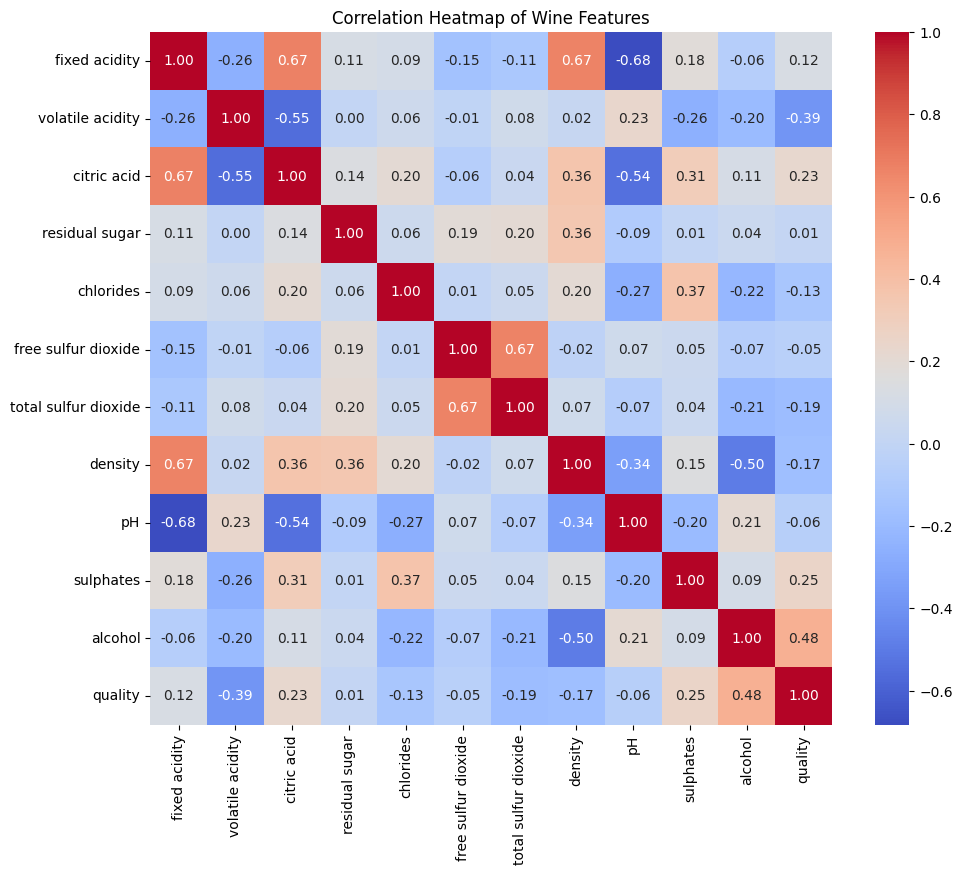

In [30]:
plt.figure(figsize=(11,9))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Wine Features")
plt.show()

"The correlation heatmap shows that alcohol has the strongest positive correlation with quality (+0.48), while volatile acidity has the strongest negative correlation (-0.39). This suggests wines with higher alcohol content and lower volatile acidity tend to be rated higher."

In [32]:
def bin_3class(q):
    if q <= 4:
        return 'low'
    elif q <= 6:
        return 'medium'
    else:
        return 'high'

df['quality_3class'] = df['quality'].apply(bin_3class)
print(df['quality_3class'].value_counts())

quality_3class
medium    1319
high       217
low         63
Name: count, dtype: int64


In [33]:
X = df[features]
y = df['quality_3class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts(normalize=True))
print("\nTest class distribution:\n", y_test.value_counts(normalize=True))

Train size: (1279, 11)  Test size: (320, 11)

Train class distribution:
 quality_3class
medium    0.824863
high      0.136044
low       0.039093
Name: proportion, dtype: float64

Test class distribution:
 quality_3class
medium    0.825000
high      0.134375
low       0.040625
Name: proportion, dtype: float64


In [34]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SGD Classifier": SGDClassifier(random_state=42, max_iter=1000),
    "SVC": SVC(kernel='rbf', random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {"model": model, "y_pred": y_pred, "accuracy": acc}
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("-"*60)

=== Random Forest ===
Accuracy: 0.8656
              precision    recall  f1-score   support

        high       0.71      0.51      0.59        43
         low       0.00      0.00      0.00        13
      medium       0.88      0.97      0.92       264

    accuracy                           0.87       320
   macro avg       0.53      0.49      0.51       320
weighted avg       0.82      0.87      0.84       320

------------------------------------------------------------
=== SGD Classifier ===
Accuracy: 0.8250
              precision    recall  f1-score   support

        high       0.52      0.33      0.40        43
         low       0.00      0.00      0.00        13
      medium       0.86      0.95      0.90       264

    accuracy                           0.82       320
   macro avg       0.46      0.42      0.43       320
weighted avg       0.78      0.82      0.80       320

------------------------------------------------------------
=== SVC ===
Accuracy: 0.8438
        

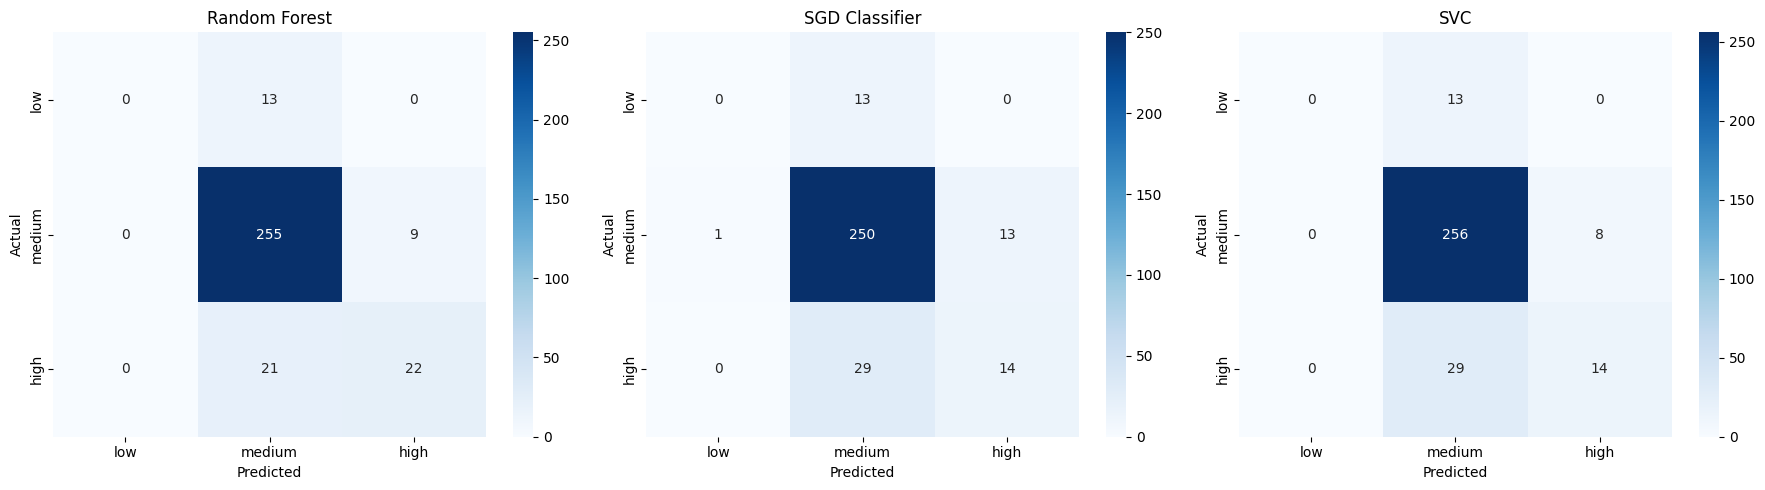

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
labels_order = ['low', 'medium', 'high']

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'], labels=labels_order)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_order, yticklabels=labels_order, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

/tmp/ipykernel_2947/623974631.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='mako')


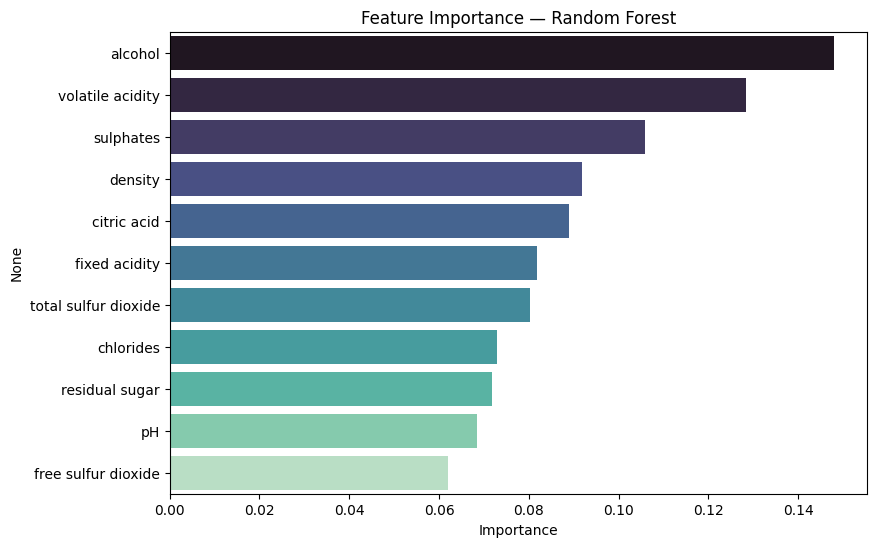

,0
alcohol,0.147945
volatile acidity,0.128305
sulphates,0.105831
density,0.091750
citric acid,0.088894
fixed acidity,0.081780
total sulfur dioxide,0.080273
chlorides,0.072976
residual sugar,0.071831
pH,0.068416


In [36]:
rf_model = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(9,6))
sns.barplot(x=importances.values, y=importances.index, palette='mako')
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.show()

importances

In [37]:
comparison = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [round(res["accuracy"], 4) for res in results.values()]
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

comparison

,Model,Accuracy
0,Random Forest,0.8656
1,SVC,0.8438
2,SGD Classifier,0.8250


"Based on the comparison table, [Random Forest / jo bhi best hai] achieved the highest accuracy at [X]%. It also provides interpretable feature importance, making it well-suited for real-world deployment in a winery quality-control setting. [SGD/SVC] performed [better/worse] but [trade-off reason — e.g., faster but less accurate / more accurate but computationally heavier]. Given the class imbalance (very few 'low' quality samples), Random Forest's ability to handle imbalanced data reasonably well via ensemble voting makes it the most practical choice for deployment."